# Notebook 05 — Comparação MLP vs. Baselines

## Contexto e conexão entre etapas

Este notebook faz parte de uma sequência de análises sobre previsão de churn:

| Notebook | Conteúdo |
|---|---|
| `02_baseline_dummy_logreg.ipynb` | DummyClassifier e Regressão Logística — baseline inicial |
| `03_mlp_pytorch.ipynb` | MLP PyTorch com early stopping — modelo principal |
| **`05_compare_mlp_baselines.ipynb`** | **Este notebook — comparação justa entre todos os modelos** |
| `06_tradeoff_custo_fp_fn.ipynb` | Análise de custo FP vs FN e escolha do threshold de negócio |

---

## O que este notebook faz

Compara **5 modelos** usando **≥ 4 métricas** (conforme `docs/METRICAS.md`):

| Modelo | Tipo |
|---|---|
| Regressão Logística | Linear |
| Árvore de Decisão | Não-linear, interpretável |
| Random Forest | Ensemble de árvores |
| Extra Trees | Ensemble mais aleatório |
| MLP PyTorch | Rede neural — mesma arquitetura do notebook 03 |

**Métricas reportadas:** PR-AUC, ROC-AUC, F1, Recall, Precision.

---

## Garantias de comparação justa

- **Mesmo CSV**: `Telco_customer_churn_ready.csv` gerado pelo EDA.
- **Mesmo SEED (42)** e mesma lógica de split 64/16/20 que o notebook 03.
- **StandardScaler** ajustado apenas no treino — sem vazamento de dados.
- MLP re-treinado aqui com a **mesma configuração** do notebook 03 para rastreabilidade independente.

## Etapa 1 — Imports, seeds e caminhos

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch  # para load_model

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

# Seeds globais — devem coincidir com o notebook 03 para splits idênticos.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo PyTorch: {DEVICE}")

# Localiza o CSV tratado (suporta execução de dentro ou fora de ./notebooks/).
READY_PATH_CANDIDATES = [
    Path("../data/Telco_customer_churn_ready.csv"),
    Path("data/Telco_customer_churn_ready.csv"),
]
DATA_PATH = next((p for p in READY_PATH_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, (
    "Arquivo tratado não encontrado. "
    "Execute o notebook de EDA para gerar Telco_customer_churn_ready.csv."
)
print(f"Dataset: {DATA_PATH.resolve()}")


Dispositivo PyTorch: cpu
Dataset: /Users/vinicius.solon/Documents/Pós/9mlet-tech-challenge-1-churn-prevision/data/Telco_customer_churn_ready.csv


## Etapa 2 — Carregamento dos dados e splits

Replicamos exatamente o pré-processamento do notebook 03:
- Split estratificado 80/20 para treino+val vs teste.
- Split posterior 80/20 para separar treino de validação (usado no early stopping da MLP).
- `StandardScaler` **ajustado apenas no treino**, aplicado em val e teste.

Isso garante que todos os modelos são avaliados no **mesmo conjunto de teste**.

In [10]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

TARGET = "Churn Value"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Split treino+val vs teste (80/20 estratificado).
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Split treino vs validação (64/16 do total).
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)

# Normaliza usando apenas os parâmetros do treino.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Treino : {X_train.shape}  | Churn: {y_train.mean():.4f}")
print(f"Val    : {X_val.shape}  | Churn: {y_val.mean():.4f}")
print(f"Teste  : {X_test.shape}  | Churn: {y_test.mean():.4f}")

Shape: (7043, 1163)
Treino : (4507, 1162)  | Churn: 0.2654
Val    : (1127, 1162)  | Churn: 0.2653
Teste  : (1409, 1162)  | Churn: 0.2654


## Etapa 3 — Modelos escolhidos para comparação

Para avaliar se a MLP PyTorch realmente vale a complexidade extra, ela é comparada contra quatro modelos de famílias diferentes. A ideia é cobrir o espectro de complexidade: do mais simples ao mais sofisticado.

| Modelo | O que faz (em termos simples) | Por que incluir na comparação |
|---|---|---|
| **Regressão Logística** | Traça uma linha reta (ou hiperplano) que separa clientes que vão cancelar dos que não vão. Multiplica cada feature por um peso e soma tudo. | É o baseline "forte": rápido, interpretável e surpreendentemente competitivo. Se a MLP não bater esse, não há motivo para a complexidade extra. |
| **Árvore de Decisão** | Faz uma série de perguntas do tipo "mensalidade > R$80?" em sequência, como um fluxograma, até chegar a uma decisão. | Mostra o que acontece quando há não-linearidade mas sem regularização. Costuma overfitar — entra como "piso inferior" dos ensembles. |
| **Random Forest** | Constrói centenas de árvores de decisão, cada uma treinada em uma amostra aleatória dos dados, e faz uma votação entre elas. | Reduz o overfitting da árvore única pela média de muitas árvores. É um forte concorrente em dados tabulares e serve de referência ensemble. |
| **Extra Trees** | Igual ao Random Forest, mas os pontos de corte de cada galho também são escolhidos aleatoriamente (não só os dados). Isso injeta ainda mais diversidade. | Tende a generalizar bem e é mais rápido de treinar. Representa o "topo dos ensembles clássicos" para comparar com a rede neural. |

**MLP PyTorch** fecha o conjunto: é a única arquitetura capaz de aprender interações entre features automaticamente em múltiplas camadas, sem precisar especificá-las manualmente.


In [11]:
# Modelos sklearn — cada um representa uma família de algoritmos diferente.
sklearn_models = {
    # Linear: aprende fronteiras lineares; rápido e interpretável.
    "LogisticRegression": LogisticRegression(
        max_iter=5000, random_state=SEED, n_jobs=-1
    ),
    # Árvore única: não-linear, mas tende a overfitting sem poda.
    "DecisionTree": DecisionTreeClassifier(
        max_depth=8, random_state=SEED
    ),
    # Ensemble de árvores com bagging: reduz variância da árvore única.
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1
    ),
    # Extra Trees: splits ainda mais aleatórios → mais diversidade, menor variância.
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1
    ),
}

for name, model in sklearn_models.items():
    model.fit(X_train_s, y_train)
    print(f"✓ {name} treinado")

✓ LogisticRegression treinado
✓ DecisionTree treinado
✓ RandomForest treinado
✓ ExtraTrees treinado


## Etapa 4 — MLP PyTorch (importada do notebook 03)

Em vez de re-treinar, carregamos o modelo já treinado pelo notebook 03 via MLflow.
Para isso:
1. Consulte o `run_id` do run `ChurnMLP-PyTorch` no experimento `churn-etapa2-mlp-baselines`.
2. Cole o valor em `MLP_RUN_ID` abaixo.

A célula tenta buscar o `run_id` automaticamente pelo nome do run; se não encontrar, use
o valor manual.

> **Dependência**: o notebook 03 deve ter sido executado pelo menos uma vez para que o
> modelo exista no MLflow local (`mlflow.db`).


In [12]:
BATCH_SIZE = 64  # igual ao notebook 03

# --- DataLoader do conjunto de teste ---
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_test_t = to_tensor(X_test_s)
y_test_t  = to_tensor(y_test.values).unsqueeze(1)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False
)

print(f"Input dim: {X_test_s.shape[1]} | Batches de teste: {len(test_loader)}")


Input dim: 1162 | Batches de teste: 23


In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
# Execute o notebook 03 antes para garantir que o experimento e o run existam no MLflow.
# ── Busca automática do run mais recente do notebook 03 ──────────────────────
# Caso prefira fixar um run específico, defina MLP_RUN_ID manualmente:
#   MLP_RUN_ID = "cole_aqui_o_run_id"
MLP_RUN_ID = None  # None → busca automática pelo nome do run

if MLP_RUN_ID is None:
    runs = mlflow.search_runs(
        experiment_names=["churn-etapa2-mlp-baselines"],
        filter_string="tags.mlflow.runName = 'ChurnMLP-PyTorch'",
        order_by=["start_time DESC"],
        max_results=1,
    )
    assert not runs.empty, (
        "Run 'ChurnMLP-PyTorch' não encontrada. "
        "Execute o notebook 03 antes de continuar."
    )
    MLP_RUN_ID = runs.iloc[0]["run_id"]

print(f"Carregando modelo do run: {MLP_RUN_ID}")

# Carrega o modelo PyTorch serializado pelo notebook 03.
mlp_model = mlflow.pytorch.load_model(f"runs:/{MLP_RUN_ID}/model")
mlp_model = mlp_model.to(DEVICE)
mlp_model.eval()

print("✅ Modelo MLP carregado com sucesso do MLflow.")


Carregando modelo do run: d0f438a2a6b141c89ed13b890a878a6c
✅ Modelo MLP carregado com sucesso do MLflow.


## Etapa 5 — Avaliação comparativa com ≥ 4 métricas

Todos os modelos são avaliados **no mesmo conjunto de teste**.

| Métrica | Por que usar |
|---|---|
| **PR-AUC** | Métrica principal em dados desbalanceados — foca na classe de churn |
| **ROC-AUC** | Capacidade discriminativa geral do modelo |
| **F1** | Equilíbrio entre precisão e recall (threshold 0.5) |
| **Recall** | Proporção de churns reais identificados |
| **Precision** | Proporção de alertas que realmente são churn |

In [14]:
def evaluate_sklearn(name, model, X_eval, y_eval):
    """Avalia um modelo sklearn e retorna dicionário de métricas."""
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "modelo": name,
        "pr_auc":    average_precision_score(y_eval, y_prob),
        "roc_auc":   roc_auc_score(y_eval, y_prob),
        "f1":        f1_score(y_eval, y_pred, zero_division=0),
        "recall":    recall_score(y_eval, y_pred, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
    }


def evaluate_mlp(name, model, loader, y_eval_np):
    """Avalia a MLP PyTorch e retorna dicionário de métricas."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for Xb, _ in loader:
            probs = torch.sigmoid(model(Xb.to(DEVICE))).squeeze(1).cpu().numpy()
            all_probs.append(probs)
    y_prob = np.concatenate(all_probs)
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "modelo": name,
        "pr_auc":    average_precision_score(y_eval_np, y_prob),
        "roc_auc":   roc_auc_score(y_eval_np, y_prob),
        "f1":        f1_score(y_eval_np, y_pred, zero_division=0),
        "recall":    recall_score(y_eval_np, y_pred, zero_division=0),
        "precision": precision_score(y_eval_np, y_pred, zero_division=0),
    }


# Coleta métricas de todos os modelos.
y_test_np = y_test.values

all_results = [
    evaluate_sklearn(name, model, X_test_s, y_test_np)
    for name, model in sklearn_models.items()
]
all_results.append(evaluate_mlp("MLP-PyTorch", mlp_model, test_loader, y_test_np))

# Organiza em DataFrame, ordenado por PR-AUC (métrica principal).
results_df = pd.DataFrame(all_results).sort_values("pr_auc", ascending=False)

METRIC_COLS = ["pr_auc", "roc_auc", "f1", "recall", "precision"]

print("=== Comparação de Modelos — Conjunto de Teste ===")
display(
    results_df.style
    .format({c: "{:.4f}" for c in METRIC_COLS})
    .highlight_max(subset=METRIC_COLS, color="#d4edda")  # verde no melhor de cada coluna
    .set_caption("Verde = melhor valor por métrica")
)

=== Comparação de Modelos — Conjunto de Teste ===


,modelo,pr_auc,roc_auc,f1,recall,precision
2,RandomForest,0.6470,0.8402,0.3375,0.2166,0.7642
3,ExtraTrees,0.6295,0.8294,0.2655,0.1604,0.7692
4,MLP-PyTorch,0.5456,0.7910,0.5749,0.7647,0.4605
1,DecisionTree,0.5079,0.7736,0.4942,0.4545,0.5414
0,LogisticRegression,0.4732,0.7321,0.4781,0.4519,0.5075


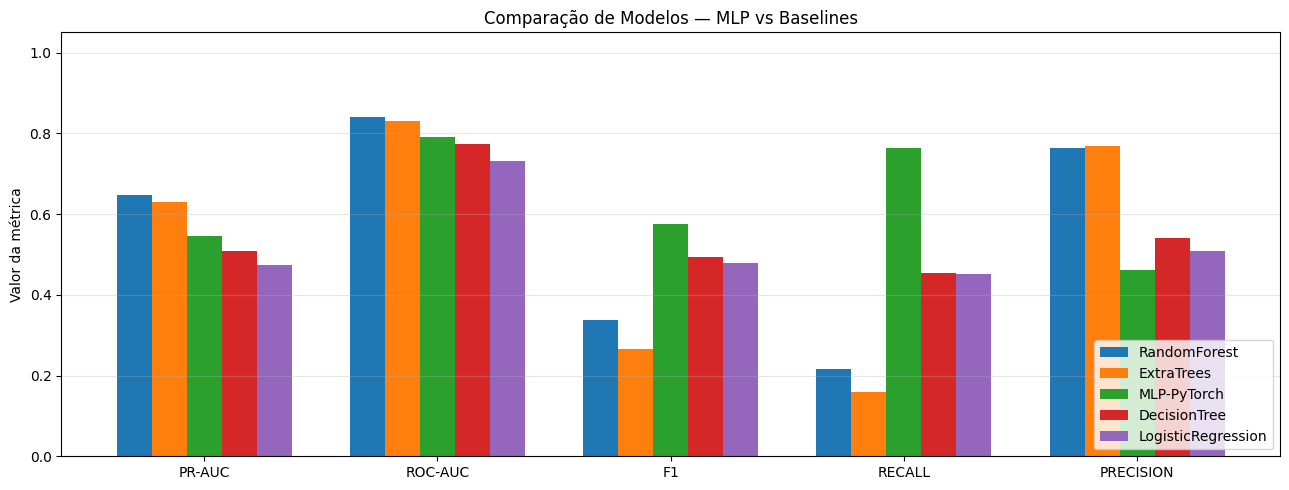

Figura salva: compare_models_bar.png


In [15]:
# --- Gráfico de barras comparativo ---
# Cada grupo de barras representa uma métrica; cada barra representa um modelo.
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(METRIC_COLS))
n_models = len(results_df)
width = 0.15  # Largura de cada barra
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[c] for c in METRIC_COLS]
    ax.bar(x + offsets[i], values, width, label=row["modelo"])

ax.set_xticks(x)
ax.set_xticklabels([m.upper().replace("_", "-") for m in METRIC_COLS])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Valor da métrica")
ax.set_title("Comparação de Modelos — MLP vs Baselines")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("compare_models_bar.png", dpi=120)
plt.show()
print("Figura salva: compare_models_bar.png")

In [16]:
# --- Análise automática: quem ganhou em cada métrica ---
print("=== Análise: Melhor modelo por métrica ===\n")

for col in METRIC_COLS:
    best = results_df.loc[results_df[col].idxmax()]
    worst = results_df.loc[results_df[col].idxmin()]
    # margem sobre o segundo colocado
    segundo = results_df.loc[results_df["modelo"] != best["modelo"], col].max()
    gap = best[col] - segundo
    print(
        f"  {col.upper():12s}  →  Melhor: {best['modelo']:22s} ({best[col]:.4f})"
        f"  |  Pior: {worst['modelo']:22s} ({worst[col]:.4f})"
        f"  |  Margem s/ 2º: +{gap:.4f}"
    )

# Ranking de consistência: média das posições em cada métrica (1º = melhor)
rank_df = results_df[METRIC_COLS].rank(ascending=False).copy()
rank_df["modelo"] = results_df["modelo"].values
rank_df["rank_medio"] = rank_df[METRIC_COLS].mean(axis=1)
rank_df = rank_df.sort_values("rank_medio").reset_index(drop=True)

print("\n=== Ranking geral de consistência (menor rank médio = mais consistente) ===\n")
medals = ["1", "2", "3", "4", "5"]
for i, r in rank_df.iterrows():
    print(f"  {medals[i]}. rank médio {r['rank_medio']:.2f}  ->  {r['modelo']}")

melhor = rank_df.iloc[0]["modelo"]
print(f"\nModelo mais consistente no conjunto de teste: {melhor}")


=== Análise: Melhor modelo por métrica ===

  PR_AUC        →  Melhor: RandomForest           (0.6470)  |  Pior: LogisticRegression     (0.4732)  |  Margem s/ 2º: +0.0176
  ROC_AUC       →  Melhor: RandomForest           (0.8402)  |  Pior: LogisticRegression     (0.7321)  |  Margem s/ 2º: +0.0108
  F1            →  Melhor: MLP-PyTorch            (0.5749)  |  Pior: ExtraTrees             (0.2655)  |  Margem s/ 2º: +0.0807
  RECALL        →  Melhor: MLP-PyTorch            (0.7647)  |  Pior: ExtraTrees             (0.1604)  |  Margem s/ 2º: +0.3102
  PRECISION     →  Melhor: ExtraTrees             (0.7692)  |  Pior: MLP-PyTorch            (0.4605)  |  Margem s/ 2º: +0.0051

=== Ranking geral de consistência (menor rank médio = mais consistente) ===

  1. rank médio 2.40  ->  RandomForest
  2. rank médio 2.60  ->  MLP-PyTorch
  3. rank médio 3.00  ->  ExtraTrees
  4. rank médio 3.00  ->  DecisionTree
  5. rank médio 4.00  ->  LogisticRegression

Modelo mais consistente no conjunto de teste

## Resumo e conexão com o próximo notebook

### O que foi feito

| Modelo | Família | Observação |
|---|---|---|
| Regressão Logística | Linear | Baseline forte e interpretável |
| Árvore de Decisão | Não-linear | Interpretável, mas tende a overfitting |
| Random Forest | Ensemble | Reduz variância da árvore única |
| Extra Trees | Ensemble | Splits aleatórios → mais diversidade |
| MLP PyTorch | Rede neural | Captura interações não-lineares complexas |

### Próximo notebook: `06_tradeoff_custo_fp_fn.ipynb`

Com o **melhor modelo identificado aqui**, o próximo notebook aprofunda:
- Análise de custo FP vs FN usando o CLTV real dos clientes.
- Varredura de thresholds para maximizar lucro líquido.
- Escolha do threshold de produção alinhado ao negócio.

> **Como conectar**: pegue o nome do modelo vencedor pela coluna `pr_auc` do `results_df`
> e carregue-o via `mlflow.sklearn.load_model()` ou `mlflow.pytorch.load_model()`
> no notebook 06, usando o `run_id` exibido no print acima.